# Classifying open-ended survey responses with text embeddings - finetuning models 

**Halvor Tyseng, Jonas Timmann Mjaaland, Markus Fleten Kreutzer and Tor Ole B. Odden**
Center for Computing in Science Education and Center for Interdisciplinary Education, University of Oslo, Norway.

**Disclaimer:** Usage of the method and code below will require a citation of this comptuational essay. Citation details pertaining to this research are found in the CITATION.cff file.

MIT License

Copyright (c) 2025 halvorty

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

# Introduction
We finetune embedding models to enhance their ability to create meaningful distinctions in our dataset. In this notebook, we will show the effect on finetuning a pre-trained sentence transformers model. Let us begin with looking at a 2D representation of where jina-embeddings-v2-small-en places the survey responses in the embedding space.

### Table of contents
1. [Using a pre-trained model for reference](#one) <br>
    1.A. [Imports and load data](#one_a) <br>
    1.B. [Initialize and visualize a pre-trained embedding model](#one_b) <br>
2. [Finetuning](#two)<br>
    2.A. [Create a finetuning dataset](#two_a)<br>
    2.B. [Finetune a pre-trained embedding model](#two_b)<br>
    2.C. [Re-embed the data and visualize the finetuned embedding model](#two_c)<br>

<a class="anchor" id="one"></a>
# 1. Using a pre-trained model for reference

<a class="anchor" id="one_a"></a>
## 1.A. Imports and load dataset

In [1]:
# Import basic libraries
import numpy as np
import pandas as pd
from itertools import product
import os
from sentence_transformers import SentenceTransformer
from datasets import Dataset
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments
)
from sentence_transformers.losses import ContrastiveLoss
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.manifold import TSNE

/opt/miniconda3/envs/ISF2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# load the dataset
dataset = pd.read_excel('data/sources_amended.xlsx')
dataset.head()

,Response,code
0,Imprecise/faulty measuring tools,L
1,air fluctuations,L
2,Slight differences in experimental setup: tabl...,L
3,The material of ramp and ball and the coeffici...,L
4,Materials issues (ball; ramps are identical),L


<a class="anchor" id="one_b"></a>
## 1.B. Initialize and visualize a pre-trained embedding model

Initialize the embedding model, load the data and embed it.

In [2]:
# initialize model and prompt
# Note: The model_name and prompt can be changed as needed.
model_name = 'jinaai/jina-embeddings-v2-base-en'
prompt = ''

model = SentenceTransformer(
    model_name,
    trust_remote_code=True
)

In [5]:
# embed the dataset
embeddings = model.encode(
    dataset['Response'].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

# add embeddings to the dataset
dataset['embedding'] = embeddings.tolist()

dataset.head()

Batches: 100%|██████████| 91/91 [00:04<00:00, 18.33it/s]


,Response,code,embedding
0,Imprecise/faulty measuring tools,L,"[-0.010014945641160011, -0.031923674046993256,..."
1,air fluctuations,L,"[-0.03653107210993767, -0.04496714472770691, 0..."
2,Slight differences in experimental setup: tabl...,L,"[-0.04071728140115738, -0.033269673585891724, ..."
3,The material of ramp and ball and the coeffici...,L,"[-0.024769000709056854, -0.057986337691545486,..."
4,Materials issues (ball; ramps are identical),L,"[0.02394707500934601, -0.04275062307715416, 0...."


Visualize using t-SNE.

In [6]:
rcParams.update({
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "font.size": 8,              
    "axes.labelsize": 6,
    "axes.titlesize": 8,
    "legend.fontsize": 6,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "grid.linewidth": 0.5,
    "lines.markersize": 3.0,
})

_MARKERS = [
    "o", "s", "D", "X", "^", "v", ">", "<", "P", "*", "+", "x"
]


def _style_lookup(codes, palette=None, markers=None):
    """Map each unique code to a colour and a marker symbol."""
    unique = list(dict.fromkeys(codes))  # preserve original order

    # --- colours ---
    if palette is None:
        palette = sns.color_palette("tab10", len(unique))
    elif isinstance(palette, dict):
        palette = [palette.get(c, "#cccccc") for c in unique]
    colours = dict(zip(unique, palette))

    # --- markers ---
    if isinstance(markers, dict):
        marker_map = {c: markers.get(c, "o") for c in unique}
    else:
        marker_cycle = markers if markers is not None else _MARKERS
        marker_map = {
            c: marker_cycle[i % len(marker_cycle)] for i, c in enumerate(unique)
        }
    return colours, marker_map


def _scatter_plot(
    xy,
    codes,
    *,
    width_cm=8.6,
    palette=None,
    markers=None,
    x_label="Component 1",
    y_label="Component 2",
    title=None,
    save_as=None,
    show_grid=True,
):
    """Internal plotting engine; returns (fig, ax)."""
    colours, marker_map = _style_lookup(codes, palette, markers)

    # Seaborn styling
    style = "whitegrid" if show_grid else "white"
    sns.set_theme()

    # Figure size
    width_in = width_cm / 2
    height_in = width_in  # square by default – override as needed

    fig, ax = plt.subplots(figsize=(width_in, width_in))

    for code in np.unique(codes):
        mask = np.asarray(codes) == code
        ax.scatter(
            xy[mask, 0],
            xy[mask, 1],
            c=[colours[code]],
            marker=marker_map[code],
            s=18,  # ≈ 3 pt at 600 dpi
            edgecolors="none",
            label=code,
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    
    ax.set_xticks([])     
    ax.set_yticks([])    

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)

    if title:
        ax.set_title(title, pad=4)
        
    ax.set_aspect("equal", adjustable="box")

    # Clean up spines but keep axes visible
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)

    ax.legend(
        title="Code",
        frameon=False,
        handletextpad=0.3,
        labelspacing=0.4,
        borderpad=0.2,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0.0,
    )

    plt.tight_layout(pad=0.2)

    if save_as:
        fig.savefig(save_as, bbox_inches="tight")
        
    return fig, ax


def plot_tsne_embeddings(
    embedding_matrix,
    codes,
    *,
    random_state=0,
    perplexity=30,
    width_cm=8.6,
    palette=None,
    markers=None,
    save_as=None,
):
    """
    Parameters
    ----------
    embedding_matrix : (n_samples, n_features) array‑like
    codes            : iterable of length n_samples
    random_state     : int, default 0
    perplexity       : float, default 30
    width_cm         : figure width in centimetres (8.6 cm = single column)
    palette, markers : dict / list / None (see _style_lookup)
    save_as          : str or path; if given, saves figure
    """
    tsne = TSNE(
        n_components=2,
        random_state=random_state,
        perplexity=perplexity,
        init="pca",
        metric="cosine",
    )
    xy = tsne.fit_transform(embedding_matrix)

    return _scatter_plot(
        xy,
        codes,
        width_cm=width_cm,
        palette=palette,
        markers=markers,
        x_label="t-SNE 1",
        y_label="t-SNE 2",
        title=None,
        save_as=save_as,
        show_grid=True,
    )

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


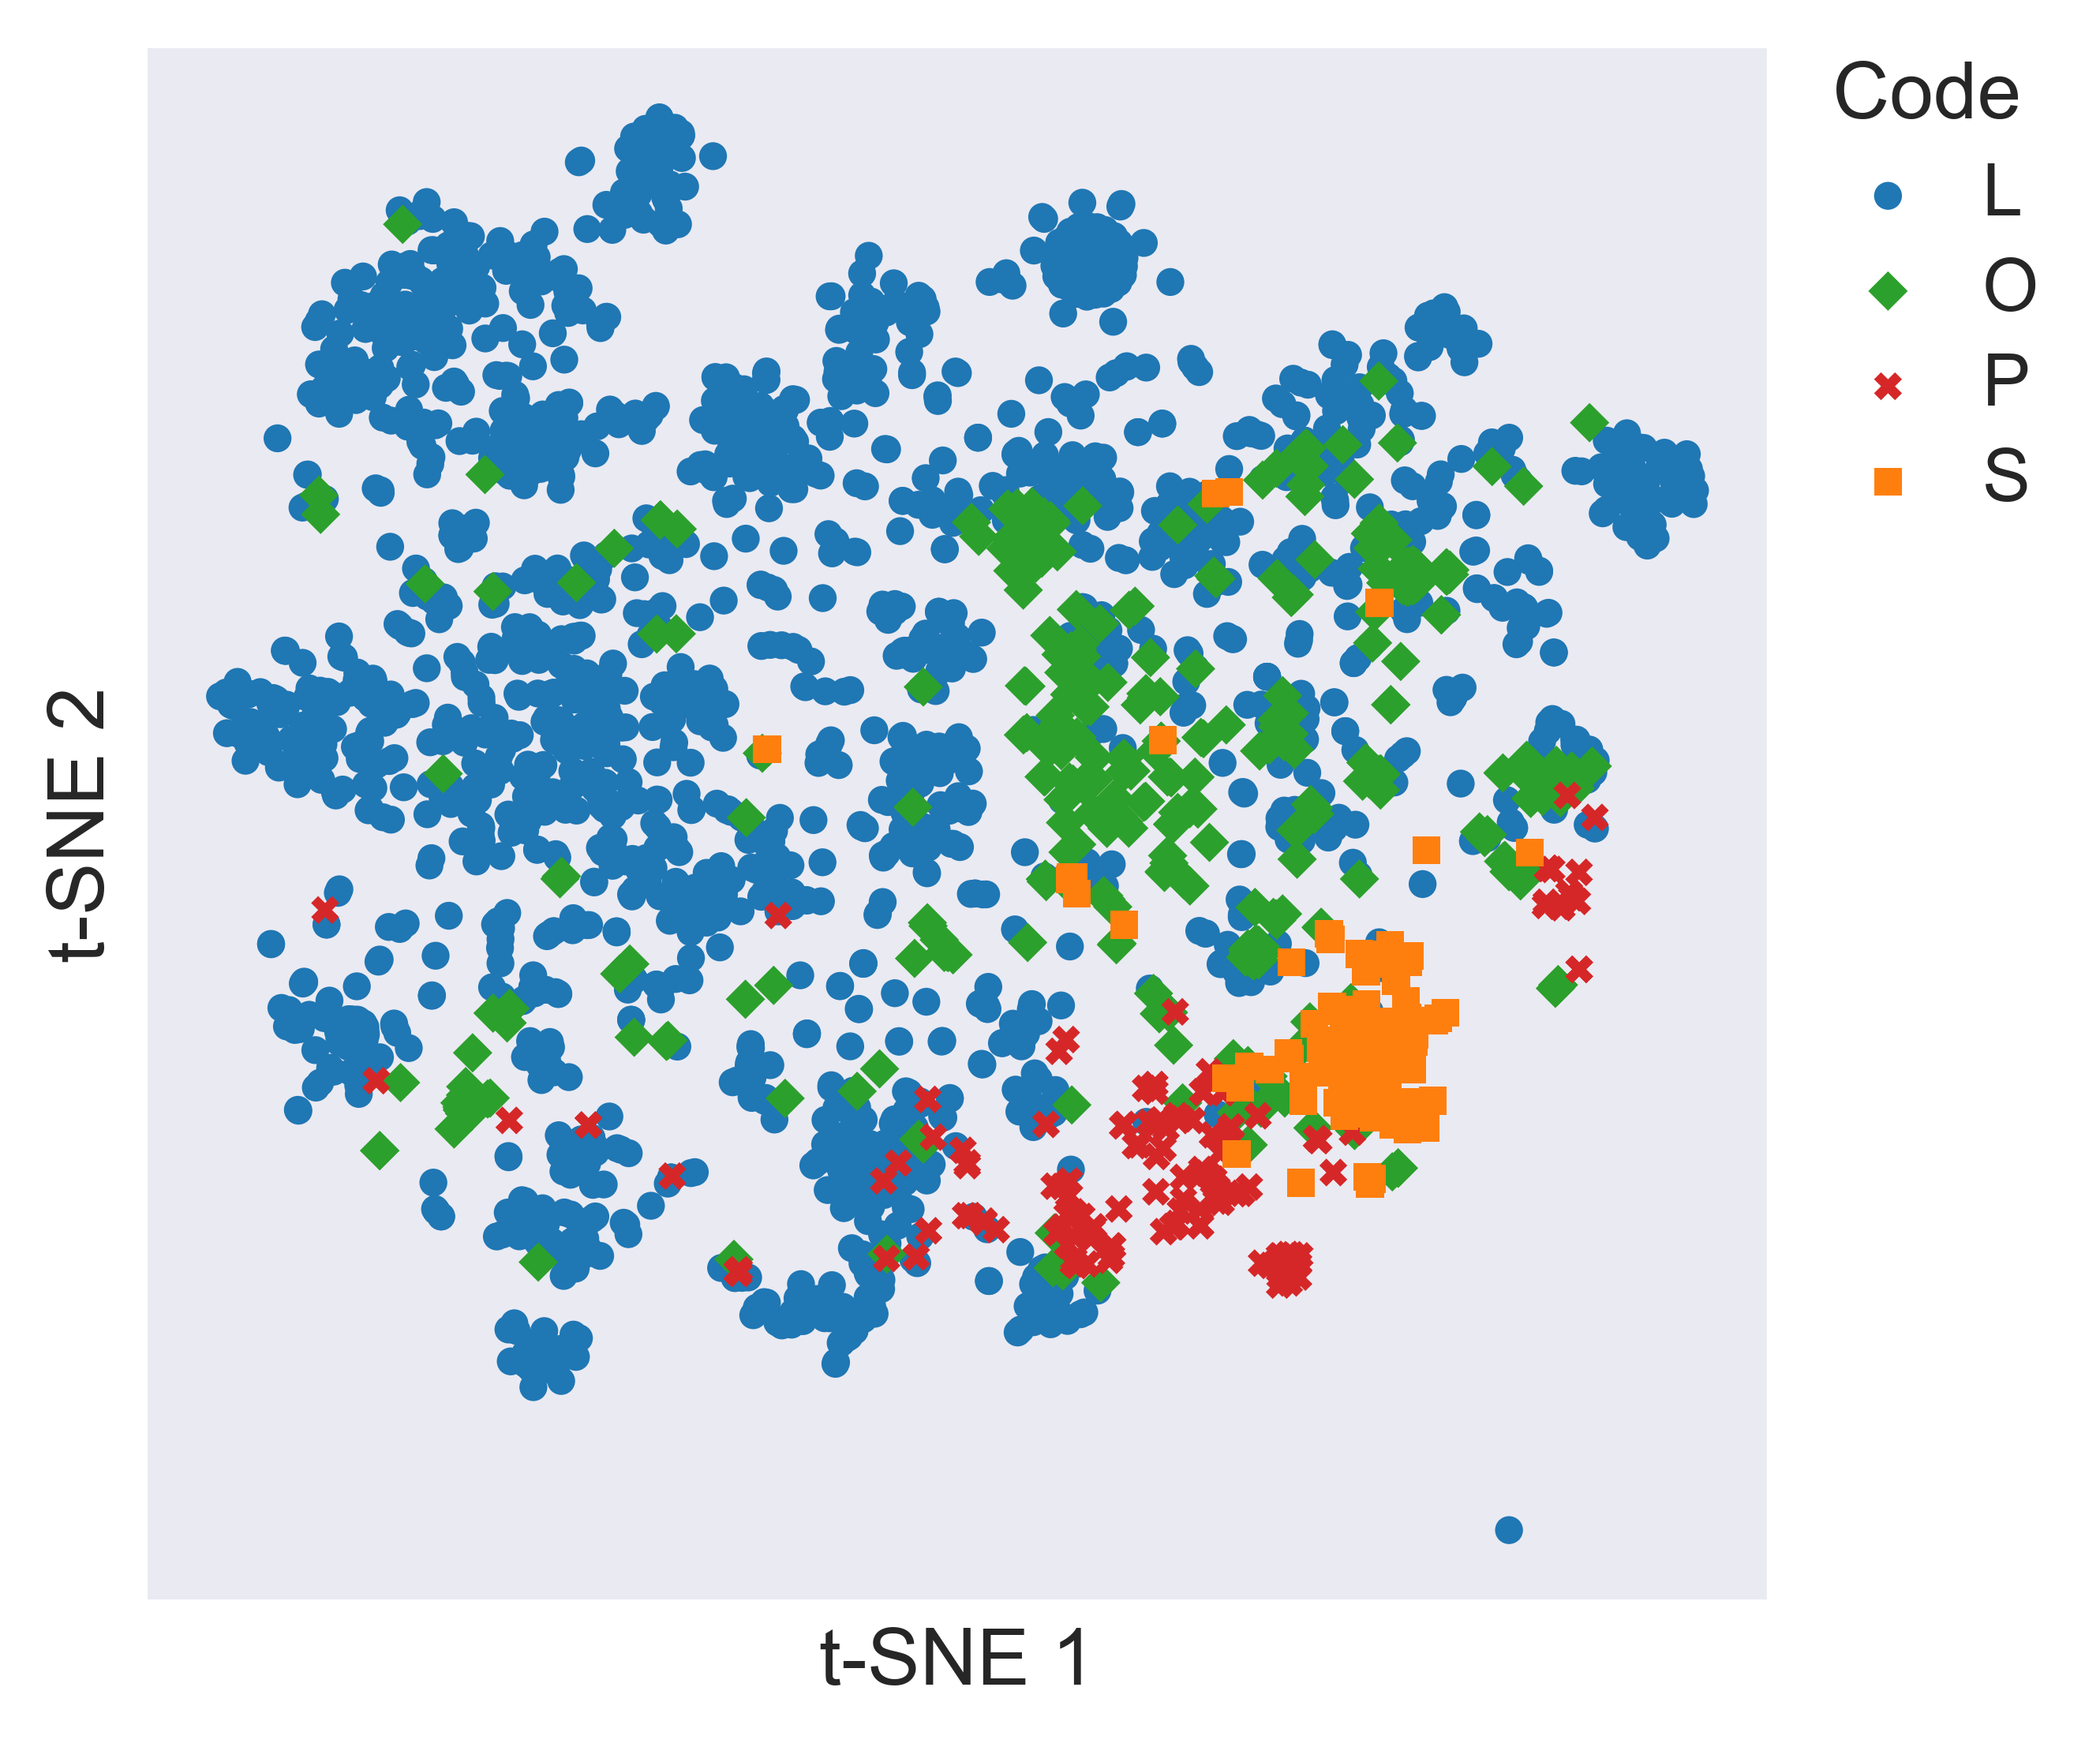

In [7]:
fig, axs = plot_tsne_embeddings(
    embedding_matrix = np.vstack(dataset['embedding']),
    codes = dataset['code'],
    save_as='tsne_no_finetune.png',
)

<a class="anchor" id="two"></a>
# 2. Finetuning

Now, let us finetune the pre-trained model we used above, and see how the landscape of responses has shifted.

<a class="anchor" id="two_a"></a>
## 2.A. Create a finetune dataset

In [8]:
def create_finetune_dataframe(centroids):

    # create a list of all the texts
    texts = centroids['text'].tolist()
    combinations = list(product(texts, repeat=2))

    # create a df with the combinations
    combinations_df = pd.DataFrame(combinations, columns=['anchor', 'target'])

    # create a function that checks if the anchor and target have the same code in centroids_df
    def check_code(anchor, target):
        anchor_code = centroids[centroids['text'] == anchor]['code'].values[0]
        target_code = centroids[centroids['text'] == target]['code'].values[0]
        if anchor_code == target_code:
            return float(1)
        else:
            return float(0)
        
    # apply the function to the df
    combinations_df['label'] = combinations_df.apply(lambda x: check_code(x['anchor'], x['target']), axis=1)

    combinations_df.rename(columns={'anchor': 'text1','target': 'text2'}, inplace=True)

    # return the df
    return combinations_df


In [9]:
# Create a finetune dataset
data = pd.read_excel('data/selected_responses.xlsx')
ft_dataframe = create_finetune_dataframe(data)

<a class="anchor" id="two_b"></a>
## 2.B. Finetune the pre-trained embedding model

In [15]:
def finetuner(model, prompt):

    # Define the filepath
    model_output_dir = f"models/{model_name}"

    # Ensure output directory exist
    os.makedirs(model_output_dir, exist_ok=True)

    # Load the dataset and define args
    ds = Dataset.from_pandas(ft_dataframe)
    training_args = SentenceTransformerTrainingArguments(
        prompts=prompt,
        output_dir=model_output_dir,
    )

    # Define the trainer
    trainer = SentenceTransformerTrainer(
        args=training_args,
        model=model,
        train_dataset=ds,
        loss= ContrastiveLoss
    )

    # Train the model
    trainer.train()

    # Save the model
    model.save_pretrained(model_output_dir)

    # Return the model
    return model

In [ ]:
# Call the finetuner on the model and prompt
ft_model = finetuner(model, prompt)

NameError: name 'finetuner' is not defined

<a class="anchor" id="two_c"></a>
## 2.C. Re-embed the data and visualize the finetuned embedding model

In [ ]:
# embed the dataset
ft_embeddings = ft_model.encode(
    dataset['Response'].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

# add finetuned embeddings to the dataset
dataset['ft_embedding'] = ft_embeddings.tolist()

dataset.head()

Batches: 100%|██████████| 91/91 [00:05<00:00, 16.53it/s]


,Response,code,embedding,ft_embedding
0,Imprecise/faulty measuring tools,L,"[-0.010014945641160011, -0.031923674046993256,...","[-0.039666302502155304, -0.008810319006443024,..."
1,air fluctuations,L,"[-0.03653107210993767, -0.04496714472770691, 0...","[-7.817517325747758e-05, -0.007827161811292171..."
2,Slight differences in experimental setup: tabl...,L,"[-0.04071728140115738, -0.033269673585891724, ...","[0.008577456697821617, -0.010145500302314758, ..."
3,The material of ramp and ball and the coeffici...,L,"[-0.024769000709056854, -0.057986337691545486,...","[0.002034008502960205, -0.015696436166763306, ..."
4,Materials issues (ball; ramps are identical),L,"[0.02394707500934601, -0.04275062307715416, 0....","[0.0025568800047039986, -0.012979025952517986,..."


## Ft t-SNE plot.

(<Figure size 2580x2580 with 1 Axes>,
 <Axes: xlabel='t-SNE\xa01', ylabel='t-SNE\xa02'>)

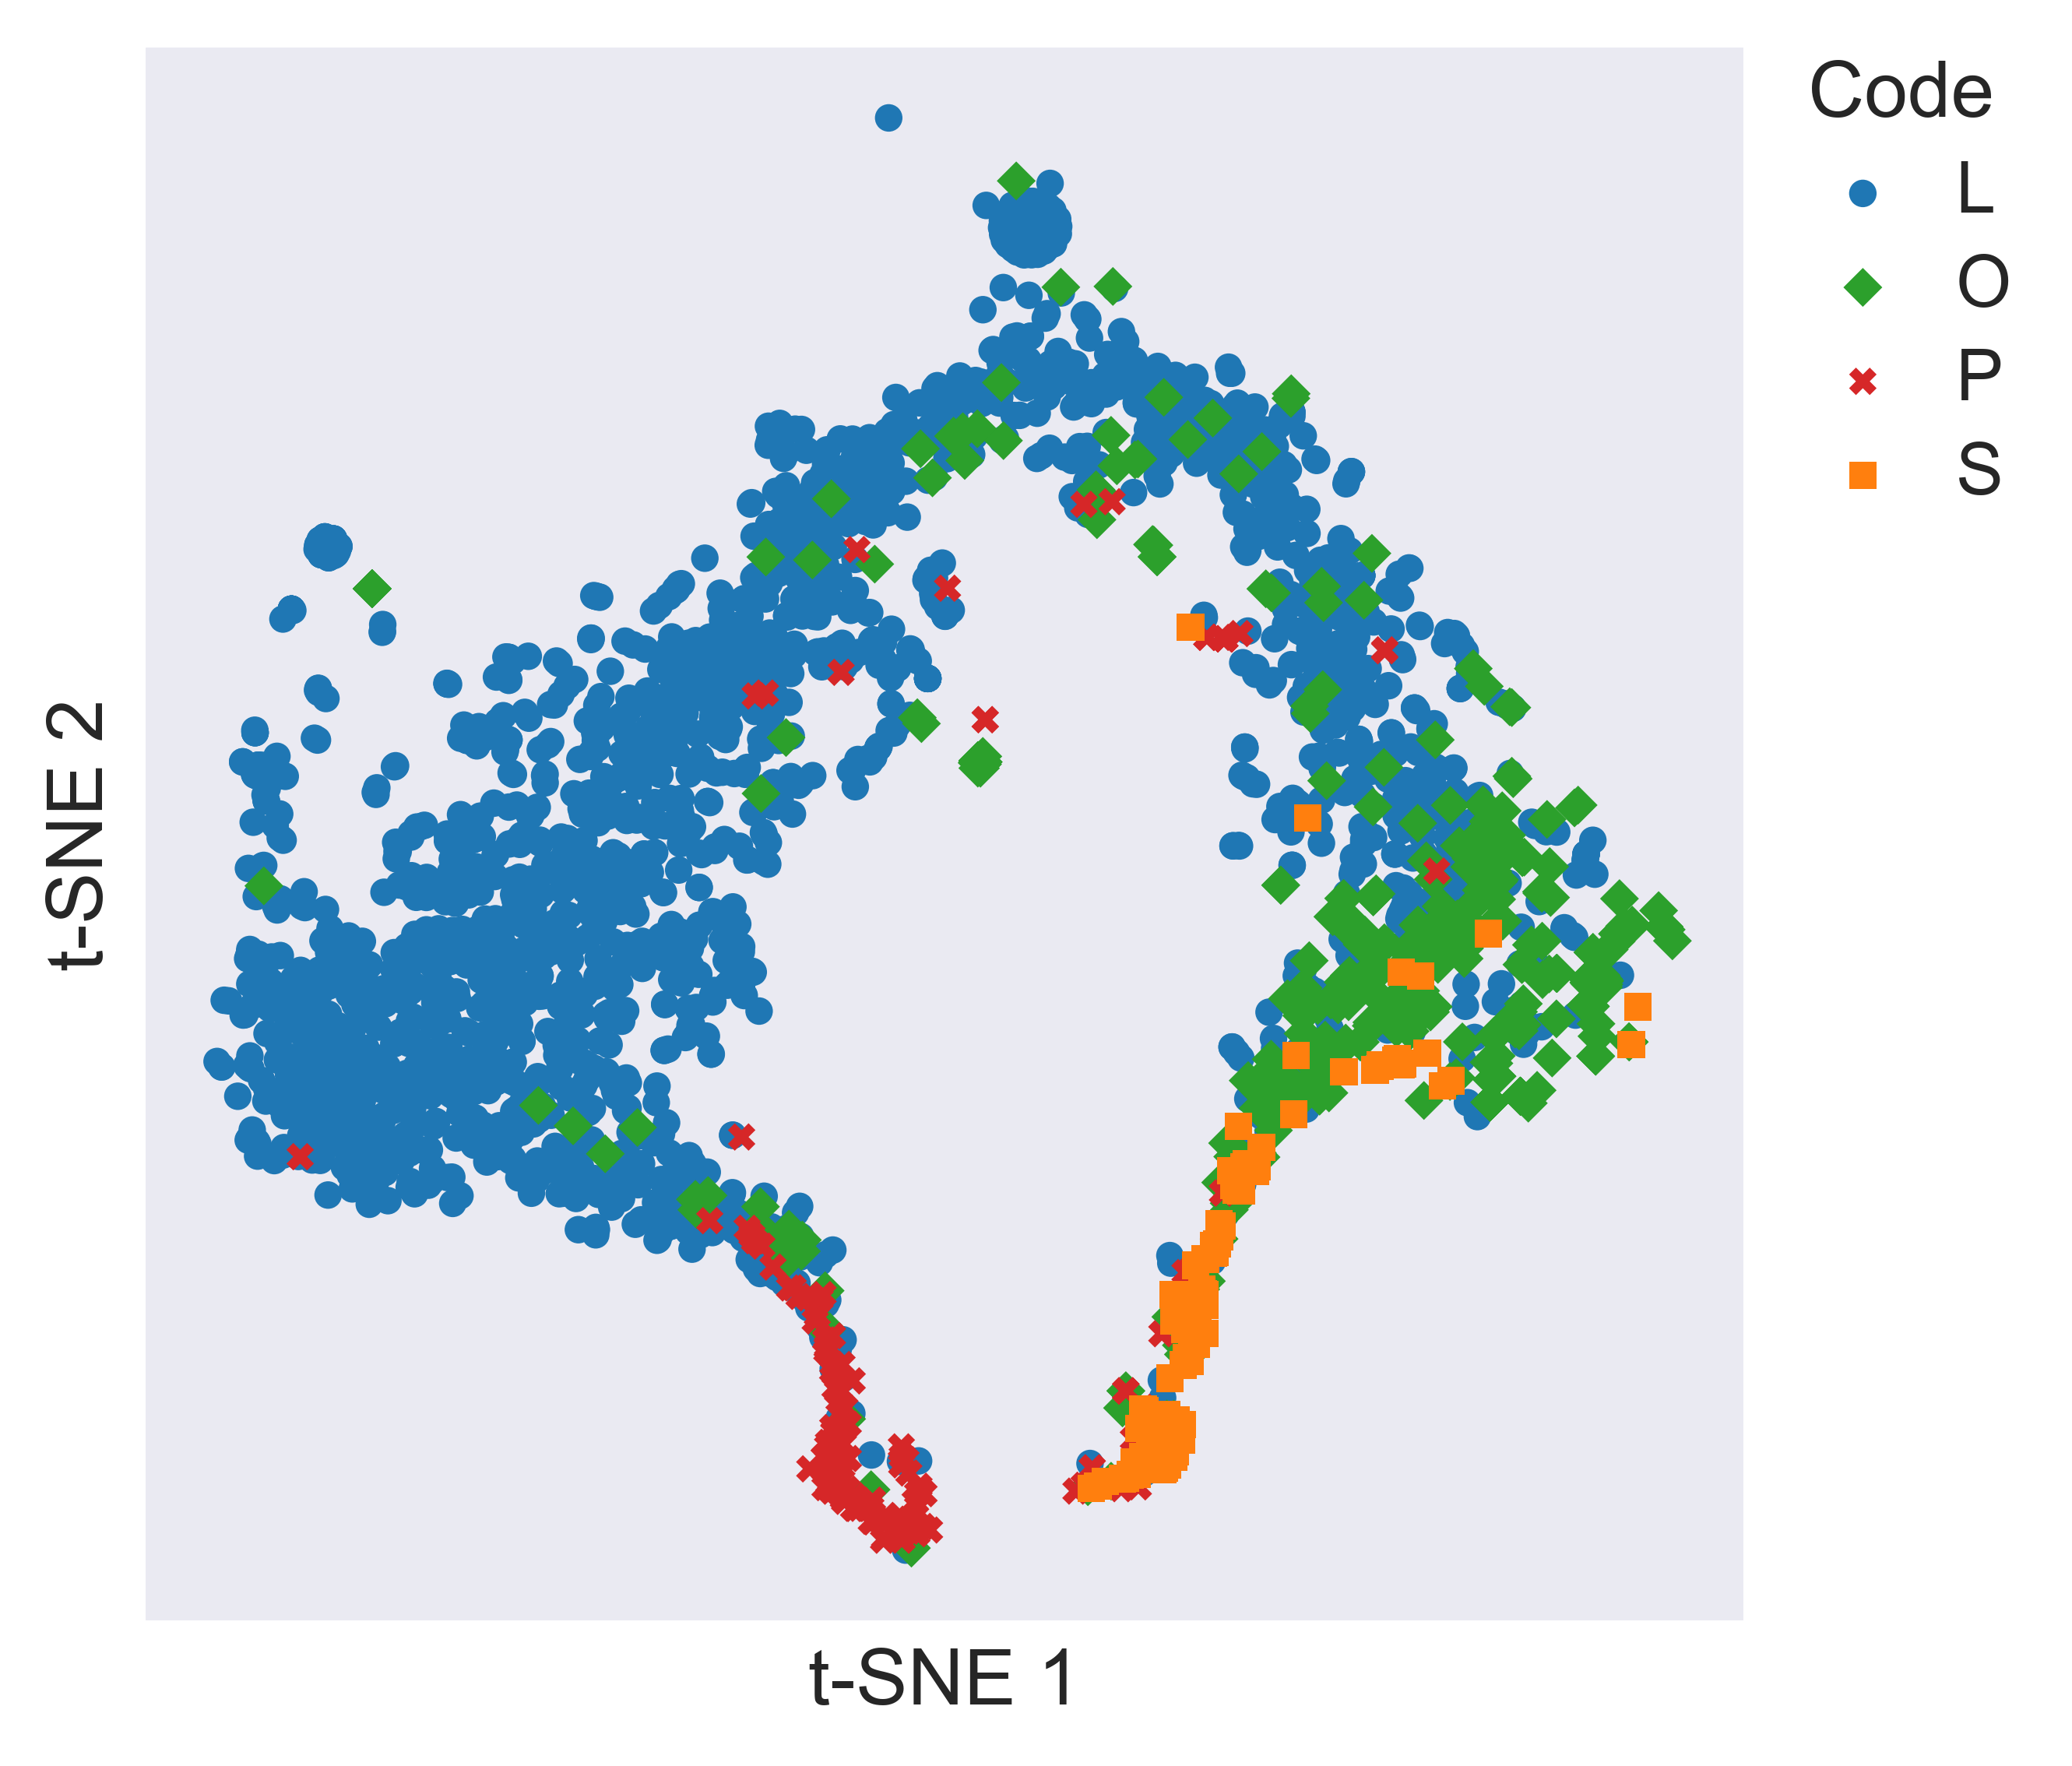

In [18]:
plot_tsne_embeddings(
    embedding_matrix = np.vstack(dataset['ft_embedding']),
    codes = dataset['code'],
    save_as='tsne_yes_finetune.png',
)